# E-Commerce Recommendation System

End-to-end demo using **Ray Data → Ray Train → Ray Data → Ray Serve** on Anyscale.

```
┌──────────────────────────────────────────────────────────────────────┐
│  Product Recommender                                                 │
│                                                                      │
│  ▼  Stage 1 — Ray Data                                               │
│       Preprocess images (resize, normalise)                          │
│       Clean text (descriptions + category)                           │
│  │                                                                   │
│  ▼  Stage 2 — Ray Train (TorchTrainer)                               │
│       Fine-tune all-MiniLM-L6-v2 with contrastive loss               │
│       Save fine-tuned model checkpoint                               │
│  │                                                                   │
│  ▼  Stage 3 — Ray Data (Batch Embedding)                             │
│       Embed entire product catalog with fine-tuned model             │
│       Save embeddings + metadata for serving                         │
│  │                                                                   │
│  ▼  Stage 4 — Ray Serve                                              │
│       POST /recommend  {image_base64}                                │
│       ImageToText  (BLIP-base)  →  caption                           │
│       ProductRecommender  (MiniLM)  →  top-5 products                │
│  │                                                                   │
│  ▼  Streamlit UI                                                     │
│       Upload image                                                   │
│                                                                      │
└──────────────────────────────────────────────────────────────────────┘
```

**Models used**
| Stage | Model | Size | Device |
|-------|-------|------|--------|
| Train | `sentence-transformers/all-MiniLM-L6-v2` | 22 M params | CPU |
| Embed | fine-tuned MiniLM | 22 M params | CPU |
| Serve | `Salesforce/blip-image-captioning-base` | 224 M params | CPU |
| Serve | fine-tuned MiniLM | 22 M params | CPU |

Everything runs on **CPU** and completes in a few minutes.

## 0 — Setup

In [1]:
# Install dependencies (skip if already installed)
!pip install -q -r setup/requirements.txt

Successfully registered `torch, transformers` and 3 other packages to be installed on all cluster nodes.
View and update dependencies here: https://console.anyscale.com/cld_lgi48eqxmyi3vubxw48uhp1z8l/prj_cy4gxzpbbyypz6z6b1vpmgvb7g/workspaces/expwrk_sdnzs12idjtp61d2rq6zxfzj57?workspace-tab=dependencies


In [2]:
import json
import os
import sys
import numpy as np
from pathlib import Path
from PIL import Image

# Make sure the project root is on the path
sys.path.insert(0, str(Path().resolve()))

from utils import PRODUCTS, CATEGORIES, get_product_image

print(f"Products in catalog : {len(PRODUCTS)}")
print(f"Categories          : {CATEGORIES}")

Products in catalog : 34
Categories          : ['Electronics', 'Clothing', 'Books', 'Home & Garden', 'Sports']


### Peek at the product images

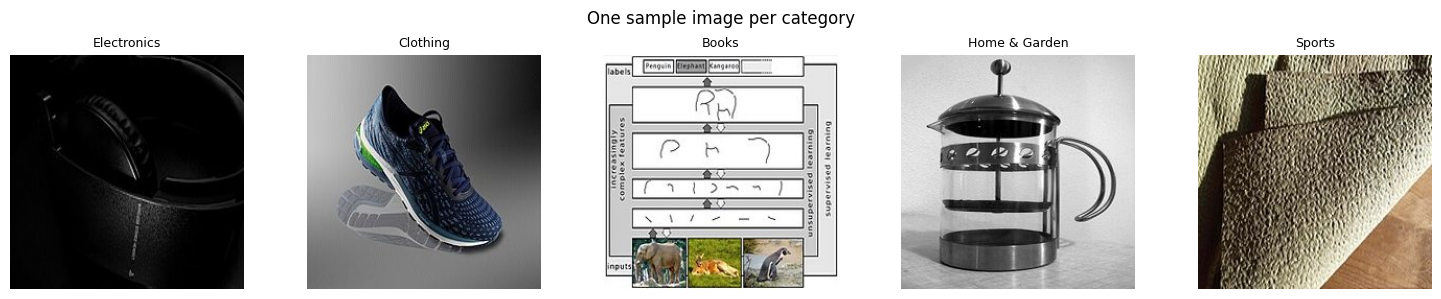

In [3]:
from utils.viz import plot_category_samples

plot_category_samples(PRODUCTS, CATEGORIES, get_product_image)

---
## Stage 1 — Catalog Generation

Here we expand the base 30-product catalog to 1,000 products and add `text_clean` (strip / lowercase / collapse whitespace on `training_text`) directly in memory — no Parquet intermediate needed.

In [4]:
import re
import ray
from utils import PRODUCTS, generate_catalog, expand_catalog, init_ray

raw_dir = os.path.abspath("data/raw")

init_ray()

# Expand the base 30-product catalog to 1,000 products.
# Variants reuse real product images but have distinct names + descriptions.
products = expand_catalog(PRODUCTS, target_size=1000)
print(f"Catalog size : {len(products)} products")
print(f"Categories   : {sorted(set(p['category'] for p in products))}")

# Generate catalog records and add cleaned text in-place
catalog_records = generate_catalog(products=products, output_dir=raw_dir)
for r in catalog_records:
    r["text_clean"] = re.sub(r'\s+', ' ', r["training_text"].strip().lower())

print(f"Catalog records : {len(catalog_records)}")

/home/ray/anaconda3/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Catalog size : 1000 products
Categories   : ['Books', 'Clothing', 'Electronics', 'Home & Garden', 'Sports']
Generated 1000 products in '/home/ray/default/data/raw'
Catalog records : 1000


---
## Stage 2 — Ray Train: Embedding Fine-Tuning

**The problem this solves:** the base `all-MiniLM-L6-v2` model was trained on generic sentence pairs and has no notion of product categories. A query like "wireless audio device" lands in the wrong neighbourhood — near books or sports items — because the model has never seen product-domain text.

Contrastive loss fixes this: same-category products are pulled together in embedding space, cross-category pairs are pushed apart. After fine-tuning, a search query lands in the right category cluster — improving recommendation precision.

We train on a stratified sample of **100 products (20 per category)** drawn from the preprocessed catalog. This keeps training fast while ensuring each category is represented. The t-SNE plot below shows how much the clusters tighten up after fine-tuning.

In [5]:
_HERE = os.path.abspath(".")

_CLUSTER_STORAGE = "/mnt/cluster_storage"
_USE_SHARED = os.path.isdir(_CLUSTER_STORAGE)

MODEL_OUTPUT_DIR = (
    os.path.join(_CLUSTER_STORAGE, "ecomm_embedding_model")
    if _USE_SHARED
    else os.path.join(_HERE, "models", "embedding_model")
)
EMBEDDINGS_PATH = os.path.join(_HERE, "models", "product_embeddings.npy")
METADATA_PATH = os.path.join(_HERE, "models", "product_metadata.json")
TRAIN_RESULT_DIR = (
    os.path.join(_CLUSTER_STORAGE, "ecomm_ray_train_results")
    if _USE_SHARED
    else os.path.join(_HERE, "models", "ray_train_results")
)

print(f"MODEL_OUTPUT_DIR : {MODEL_OUTPUT_DIR}")
print(f"TRAIN_RESULT_DIR : {TRAIN_RESULT_DIR}")

MODEL_OUTPUT_DIR : /mnt/cluster_storage/ecomm_embedding_model
TRAIN_RESULT_DIR : /mnt/cluster_storage/ecomm_ray_train_results


In [6]:
from collections import defaultdict as _defaultdict
import random as _random

# Sample 20 products per category — enough contrastive pairs for fine-tuning,
# fast enough to finish in a couple of minutes on CPU.
TRAIN_PER_CATEGORY = 20
_by_cat = _defaultdict(list)
for _r in catalog_records:
    _by_cat[_r["category"]].append(_r)
_rng = _random.Random(42)
train_records = []
for _cat_rows in _by_cat.values():
    train_records.extend(_rng.sample(_cat_rows, min(TRAIN_PER_CATEGORY, len(_cat_rows))))
print(
    f"Sampled {len(train_records)} training records  ({len(_by_cat)} categories × ~{TRAIN_PER_CATEGORY} each)"
)

Sampled 100 training records  (5 categories × ~20 each)


In [7]:
# TorchTrainer: 1 worker, contrastive loss pulls same-category pairs together
import torch
from ray.train import CheckpointConfig, FailureConfig, RunConfig, ScalingConfig
from ray.train.torch import TorchTrainer
from utils.training import train_loop_per_worker

trainer = TorchTrainer(
    train_loop_per_worker=train_loop_per_worker,
    train_loop_config={
        "base_model": "sentence-transformers/all-MiniLM-L6-v2",
        "epochs": 2,
        "batch_size": 8,
        "lr": 2e-5,
        "seed": 42,
        "records": train_records,
    },
    scaling_config=ScalingConfig(num_workers=1, use_gpu=torch.cuda.is_available()),
    run_config=RunConfig(
        name="ecomm_embedding_finetune",
        storage_path=os.path.abspath(TRAIN_RESULT_DIR),
        checkpoint_config=CheckpointConfig(
            num_to_keep=2,
            checkpoint_score_attribute="train_loss",
            checkpoint_score_order="min",
        ),
        failure_config=FailureConfig(max_failures=1),
    ),
)
print("TorchTrainer configured")

TorchTrainer configured


In [8]:
result = trainer.fit()
print(result.metrics_dataframe[["epoch", "train_loss"]].to_string(index=False))

# Restore the best checkpoint and save as a SentenceTransformer for easy serving
from sentence_transformers import SentenceTransformer

Path(MODEL_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
checkpoint = result.best_checkpoints[0][0]
with checkpoint.as_directory() as ckpt_dir:
    model = SentenceTransformer(ckpt_dir)
    model.save(MODEL_OUTPUT_DIR)
print(f"Model saved → {MODEL_OUTPUT_DIR}")

 epoch  train_loss
     0    0.338744
     1    0.202505


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved → /mnt/cluster_storage/ecomm_embedding_model


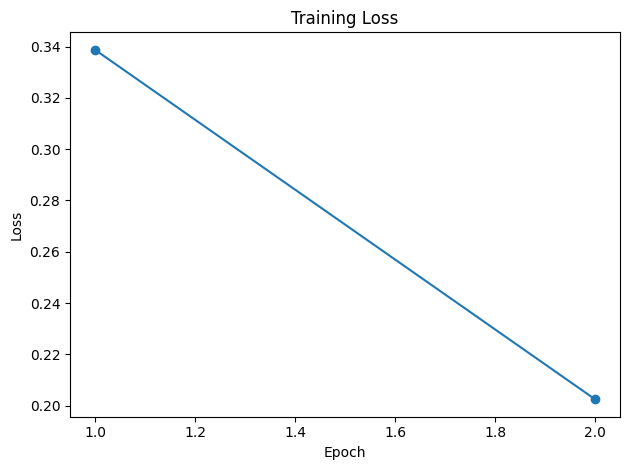

In [9]:
from utils.viz import plot_training_loss

plot_training_loss(result.metrics_dataframe)

---
## Stage 3 — Ray Data: Batch Embedding

**The problem this solves:** embedding 1,000 products serially with a model loaded once per process is slow. Worse, at 1M products you can't fit the whole catalog in memory on one machine.

Ray Data solves both: each actor loads the fine-tuned model **once**, then processes a steady stream of batches. Workers run in parallel, and Ray's streaming execution means only a slice of the catalog is in memory at any time. The same code scales from 1,000 to 100M products by adjusting `concurrency`.

In [10]:
import ray
from utils import init_ray

init_ray()

ds = ray.data.from_items(catalog_records).select_columns(
    ["product_id", "name", "category", "text_clean"]
)
print(f"Rows to embed: {ds.count()}")

2026-04-19 18:30:30,136	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 28.0% of available memory (17.9GiB out of 64.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.


Rows to embed: 1000


In [11]:
# Actor pool: each worker loads the fine-tuned model once and encodes batches in parallel
from pathlib import Path
from utils.embedding import ProductEmbedder

assert Path(MODEL_OUTPUT_DIR).exists() and any(Path(MODEL_OUTPUT_DIR).iterdir()), \
    f"Model not found at {MODEL_OUTPUT_DIR} — run Stage 2 first"

rows = ds.map_batches(
    ProductEmbedder,
    fn_constructor_kwargs={"model_dir": MODEL_OUTPUT_DIR},
    batch_size=8,
    num_cpus=1,
    concurrency=2,
    batch_format="numpy",
).take_all()
print(f"Embedded {len(rows)} products")

2026-04-19 18:30:32,591	WARNING util.py:642 -- The argument ``concurrency`` is deprecated in Ray 2.51. Please specify argument ``compute`` instead. For more information, see https://docs.ray.io/en/master/data/transforming-data.html#stateful-transforms.
{"asctime":"2026-04-19 18:30:32,617","levelname":"E","message":"Actor with class name: 'MapWorker(Project->MapBatches(ProductEmbedder))' and ID: 'c0ade7a54989c29132006f0c07000000' has constructor arguments in the object store and max_restarts > 0. If the arguments in the object store go out of scope or are lost, the actor restart will fail. See https://github.com/ray-project/ray/issues/53727 for more details.","filename":"core_worker.cc","lineno":2194}


Embedded 1000 products


In [12]:
# Collect embedding vectors and save to disk
import numpy as np
import json

embeddings = np.array([r["embedding"] for r in rows])
metadata = [
    {"product_id": r["product_id"], "name": r["name"], "category": r["category"]}
    for r in rows
]

Path(EMBEDDINGS_PATH).parent.mkdir(parents=True, exist_ok=True)
np.save(EMBEDDINGS_PATH, embeddings)
with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Embeddings : {embeddings.shape}  →  {EMBEDDINGS_PATH}")
print(f"Metadata   : {len(metadata)} products  →  {METADATA_PATH}")

Embeddings : (1000, 384)  →  /home/ray/default/models/product_embeddings.npy
Metadata   : 1000 products  →  /home/ray/default/models/product_metadata.json


Embeddings shape : (1000, 384)
Products indexed : 1000


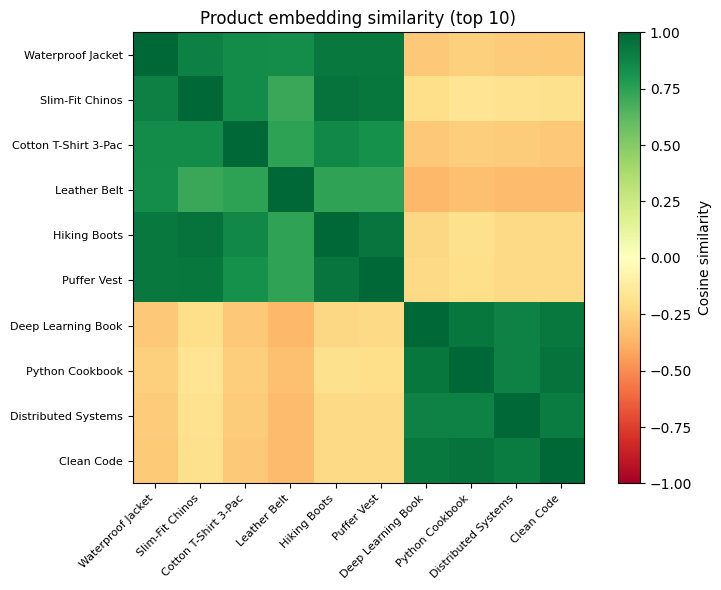

In [13]:
from utils.viz import plot_similarity_heatmap

embeddings = np.load("models/product_embeddings.npy")
with open("models/product_metadata.json") as f:
    metadata = json.load(f)

print(f"Embeddings shape : {embeddings.shape}")
print(f"Products indexed : {len(metadata)}")

plot_similarity_heatmap(embeddings, [m["name"] for m in metadata])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


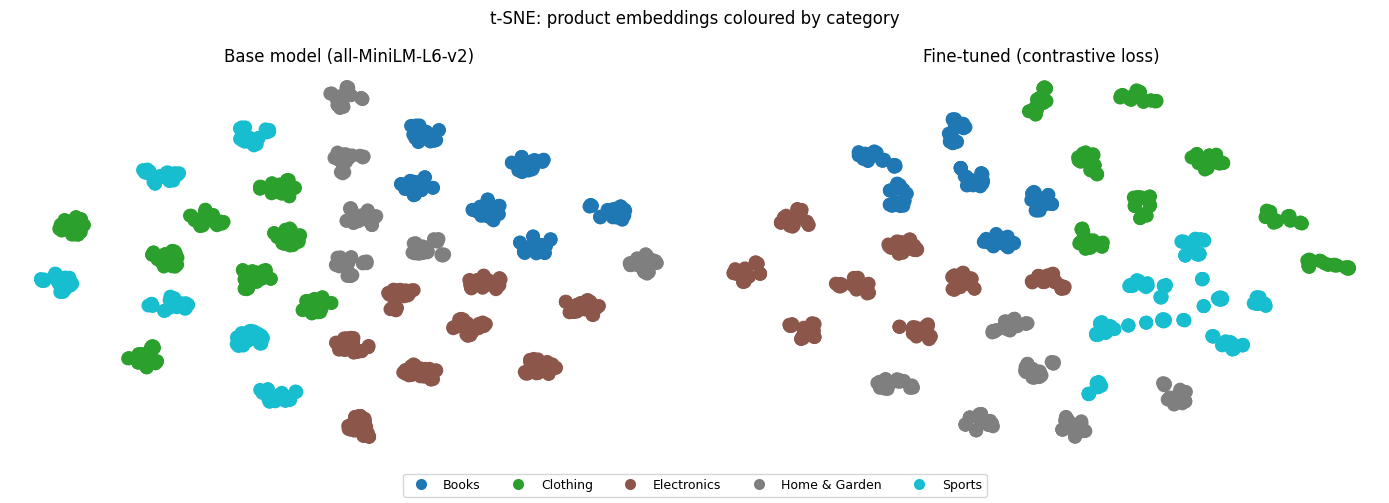

In [14]:
from utils.viz import plot_tsne_comparison

base_embs, ft_embs, aligned_meta = plot_tsne_comparison(
    metadata, embeddings, catalog_records=catalog_records
)

In [15]:
from utils.viz import compute_category_precision_at_k

p_base_5 = compute_category_precision_at_k(base_embs, aligned_meta, k=5)
p_ft_5   = compute_category_precision_at_k(ft_embs,   aligned_meta, k=5)
p_base_1 = compute_category_precision_at_k(base_embs, aligned_meta, k=1)
p_ft_1   = compute_category_precision_at_k(ft_embs,   aligned_meta, k=1)

print(f"Base model   P@5: {p_base_5:.1%}   P@1: {p_base_1:.1%}")
print(f"Fine-tuned   P@5: {p_ft_5:.1%}   P@1: {p_ft_1:.1%}")
print(f"Improvement  P@5: +{p_ft_5 - p_base_5:.1%}   P@1: +{p_ft_1 - p_base_1:.1%}")

Base model   P@5: 100.0%   P@1: 100.0%
Fine-tuned   P@5: 100.0%   P@1: 100.0%
Improvement  P@5: +0.0%   P@1: +0.0%


---
## Stage 4 — Ray Serve: Online Recommendation API

**The problem this solves:** BLIP (224M params) and MiniLM (22M params) have very different latency, throughput, and resource profiles. Bundling them into one process means the slower model throttles the faster one.

Ray Serve deploys them as **independent deployments** that auto-scale separately. `ImageToText` can scale to 4 replicas for a spike in image uploads without adding MiniLM replicas you don't need. Both can be upgraded or rolled back independently, and the composing `RecommendationService` wires them together asynchronously behind a single `/recommend` endpoint.

In [16]:
import os
import ray
from ray import serve
from utils import init_ray

init_ray()

_CLUSTER_STORAGE = "/mnt/cluster_storage"
_USE_SHARED = os.path.isdir(_CLUSTER_STORAGE)

# Force-assign paths so stale env vars from previous runs don't leak to workers.
os.environ["EMBEDDING_MODEL_DIR"] = MODEL_OUTPUT_DIR
os.environ["EMBEDDINGS_PATH"] = (
    os.path.join(_CLUSTER_STORAGE, "ecomm_product_embeddings.npy")
    if _USE_SHARED
    else EMBEDDINGS_PATH
)
os.environ["METADATA_PATH"] = (
    os.path.join(_CLUSTER_STORAGE, "ecomm_product_metadata.json")
    if _USE_SHARED
    else METADATA_PATH
)

import importlib, serve_app
importlib.reload(serve_app)
from serve_app import app

serve.run(app)
print("Service running at http://localhost:8000")

Service running at http://localhost:8000


In [17]:
# --- Test the endpoint ---
import base64, io, requests
from utils import get_product_image, PRODUCTS

# Build a test image (Wireless Headphones)
product = PRODUCTS[0]
img_arr = get_product_image(product)
img_pil = Image.fromarray(img_arr)

buf = io.BytesIO()
img_pil.save(buf, format="JPEG")
encoded = base64.b64encode(buf.getvalue()).decode()

resp = requests.post("http://localhost:8000/recommend", json={"image_base64": encoded})
result = resp.json()

print(f"Caption : {result['caption']!r}")
print(f"\nTop-{len(result['recommendations'])} recommendations:")
for r in result["recommendations"]:
    print(
        f"  {r['rank']}. [{r['category']:18s}] {r['name']:35s}  sim={r['similarity']:.3f}"
    )

Caption : 'a pair of headphones on a black background'

Top-5 recommendations:
  1. [Electronics       ] Travel Wireless Headphones           sim=0.568
  2. [Electronics       ] Travel Wireless Headphones           sim=0.568
  3. [Electronics       ] Wireless Headphones                  sim=0.562
  4. [Electronics       ] Wireless Headphones                  sim=0.562
  5. [Electronics       ] Advanced Wireless Headphones         sim=0.555


In [18]:
# One test image per category — prove the pipeline generalises
print(f"{'Category':<16} {'Caption':<45} {'Top recommendation'}")
print("-" * 85)
for cat in CATEGORIES:
    prod = next(p for p in PRODUCTS if p["category"] == cat)
    img = Image.fromarray(get_product_image(prod))
    buf = io.BytesIO()
    img.save(buf, format="JPEG")
    r = requests.post(
        "http://localhost:8000/recommend",
        json={"image_base64": base64.b64encode(buf.getvalue()).decode()},
    ).json()
    top = r["recommendations"][0]
    print(
        f"{cat:<16} {r['caption'][:44]:<45} {top['name'][:20]} ({top['similarity']:.2f})"
    )

Category         Caption                                       Top recommendation
-------------------------------------------------------------------------------------
Electronics      a pair of headphones on a black background    Travel Wireless Head (0.57)
Clothing         a pair of running shoes on a black backgroun  Signature Running Sh (0.77)
Books            a diagram showing the different stages of th  Sport Designing Data (0.15)
Home & Garden    a coffee pot and a coffee pot on a table      Signature French Pre (0.74)
Sports           a pile of rugs on a wooden floor              Succulent Set 6-Pack (0.47)


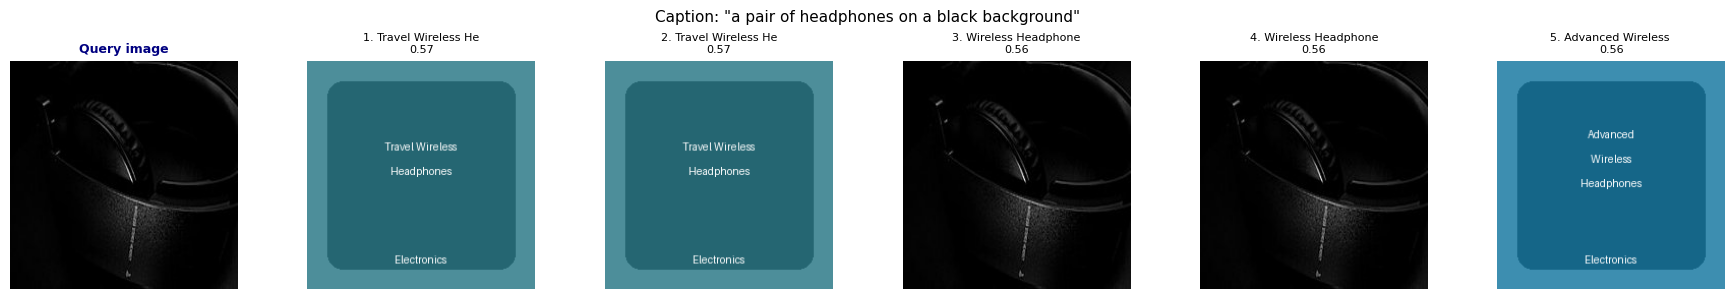

In [19]:
# Show the query image alongside recommendations
from utils.viz import plot_recommendations

plot_recommendations(
    img_arr, result["recommendations"], PRODUCTS, result["caption"], get_product_image
)

In [20]:
# Teardown (optional — keep the service running if you want to use the Streamlit app)
# serve.shutdown()

## Streamlit UI

With the service running, open a terminal and run:

```bash
streamlit run streamlit_app.py --server.port 8501 --server.address 0.0.0.0
```

Then in the workspace > Overview > Open Ports > Open (where it says Port 8501 - Streamlit) > Authenticate